# Explore heuristic values for an empty maze

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## Create the maze representation

Define an empty $10 \times 10$ maze and place the start and goal. The figures retain one-based coordinate labels, while the NumPy array uses zero-based indices.

In [2]:
n = 10
start = np.array([1, 1])
goal = np.array([8, 8])

maze = np.full((n, n), " ", dtype=str)
maze[tuple(start)] = "S"
maze[tuple(goal)] = "G"
maze

array([[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', 'S', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', 'G', ' '],
       [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']], dtype='<U1')

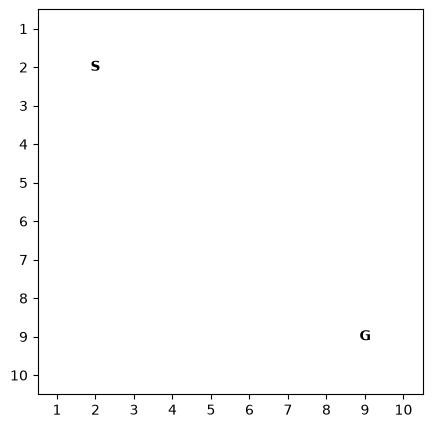

In [3]:
def show_values(values, cmap="YlOrRd_r", colorbar=True):
    """Display values on the maze and mark the start and goal."""
    figure, axis = plt.subplots(figsize=(6, 5))
    image = axis.imshow(values, cmap=cmap, origin="upper")
    axis.set_xticks(range(n), labels=range(1, n + 1))
    axis.set_yticks(range(n), labels=range(1, n + 1))
    axis.text(goal[1], goal[0], "G", ha="center", va="center", fontweight="bold")
    axis.text(start[1], start[0], "S", ha="center", va="center", fontweight="bold")
    if colorbar:
        figure.colorbar(image, ax=axis, label="value")
    plt.show()


show_values(np.zeros((n, n)), cmap="Greys", colorbar=False)

## GBFS: Use Manhattan Distance for $h(n)$

Manhattan distance is also called the $L_1$ norm. It is the difference in x values plus the difference in y values: $L_1(a,b) = |a_x-b_x| + |a_y-b_y|$.

Manhattan distance is a perfect heuristic for the maze: $h(n) = h^*(n)$ and $f(n) = f^*(n)$ (the asterisk represents the optimal value). Calculate $h(n)$.

[[16 15 14 13 12 11 10  9  8  9]
 [15 14 13 12 11 10  9  8  7  8]
 [14 13 12 11 10  9  8  7  6  7]
 [13 12 11 10  9  8  7  6  5  6]
 [12 11 10  9  8  7  6  5  4  5]
 [11 10  9  8  7  6  5  4  3  4]
 [10  9  8  7  6  5  4  3  2  3]
 [ 9  8  7  6  5  4  3  2  1  2]
 [ 8  7  6  5  4  3  2  1  0  1]
 [ 9  8  7  6  5  4  3  2  1  2]]


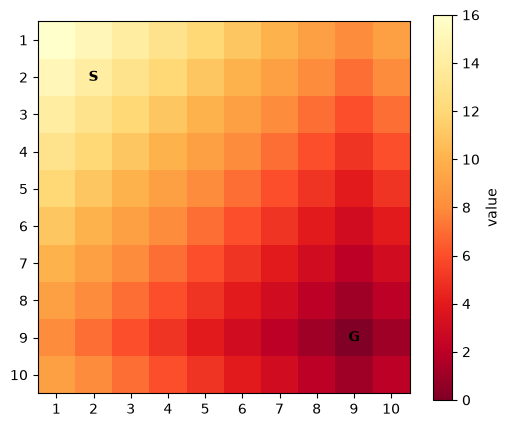

In [4]:
rows, columns = np.indices((n, n))
h_manhattan = np.abs(rows - goal[0]) + np.abs(columns - goal[1])
print(h_manhattan)
show_values(h_manhattan)

The algorithm will follow the color gradient from dark red to light yellow.

## A* with Manhattan heuristic

Calculate $f(n) = g(n) + h(n)$.

[[18 16 16 16 16 16 16 16 16 18]
 [16 14 14 14 14 14 14 14 14 16]
 [16 14 14 14 14 14 14 14 14 16]
 [16 14 14 14 14 14 14 14 14 16]
 [16 14 14 14 14 14 14 14 14 16]
 [16 14 14 14 14 14 14 14 14 16]
 [16 14 14 14 14 14 14 14 14 16]
 [16 14 14 14 14 14 14 14 14 16]
 [16 14 14 14 14 14 14 14 14 16]
 [18 16 16 16 16 16 16 16 16 18]]


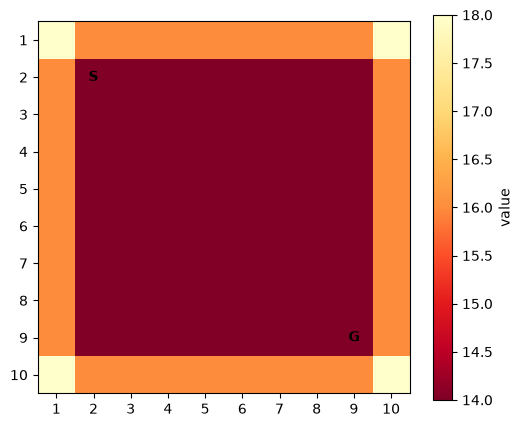

In [5]:
g = np.abs(rows - start[0]) + np.abs(columns - start[1])
f = g + h_manhattan
print(f)
show_values(f)

**Note:** In Manhattan geometry, all paths that go directly from $S$ to $G$ are optimal and have the same distance. Even with a perfect heuristic, the agent faces a plateau of positions with exactly the same $f(n) = C^*$. All directions are tied, so the tie-breaking strategy is important.

[Amit Patel's discussion of heuristics](http://theory.stanford.edu/~amitp/GameProgramming/Heuristics.html) describes this and other issues and suggests increasing the value of $h(n)$ by a small factor, leading to weighted A* search.

## Weighted A* Search

Use $f(n) = g(n) + W \times h(n)$, with $W > 0$. For $W>1$, this is not guaranteed to be optimal because the weighted heuristic may become inadmissible, but it can reduce search time and memory. First, inflate the heuristic by 10%.

[[19.6 17.5 17.4 17.3 17.2 17.1 17.  16.9 16.8 18.9]
 [17.5 15.4 15.3 15.2 15.1 15.  14.9 14.8 14.7 16.8]
 [17.4 15.3 15.2 15.1 15.  14.9 14.8 14.7 14.6 16.7]
 [17.3 15.2 15.1 15.  14.9 14.8 14.7 14.6 14.5 16.6]
 [17.2 15.1 15.  14.9 14.8 14.7 14.6 14.5 14.4 16.5]
 [17.1 15.  14.9 14.8 14.7 14.6 14.5 14.4 14.3 16.4]
 [17.  14.9 14.8 14.7 14.6 14.5 14.4 14.3 14.2 16.3]
 [16.9 14.8 14.7 14.6 14.5 14.4 14.3 14.2 14.1 16.2]
 [16.8 14.7 14.6 14.5 14.4 14.3 14.2 14.1 14.  16.1]
 [18.9 16.8 16.7 16.6 16.5 16.4 16.3 16.2 16.1 18.2]]


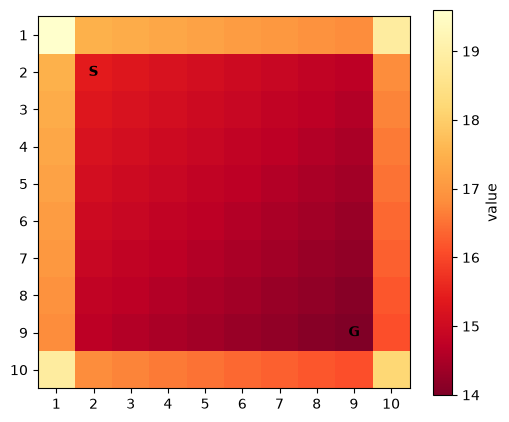

In [6]:
f = g + 1.10 * h_manhattan
print(f)
show_values(f)

The gradient is subtle, but it leads directly from $S$ to $G$. Now try $W=5$. As $W$ increases, weighted A* approaches GBFS, which completely ignores $g(n)$.

[[82 76 72 68 64 60 56 52 48 54]
 [76 70 66 62 58 54 50 46 42 48]
 [72 66 62 58 54 50 46 42 38 44]
 [68 62 58 54 50 46 42 38 34 40]
 [64 58 54 50 46 42 38 34 30 36]
 [60 54 50 46 42 38 34 30 26 32]
 [56 50 46 42 38 34 30 26 22 28]
 [52 46 42 38 34 30 26 22 18 24]
 [48 42 38 34 30 26 22 18 14 20]
 [54 48 44 40 36 32 28 24 20 26]]


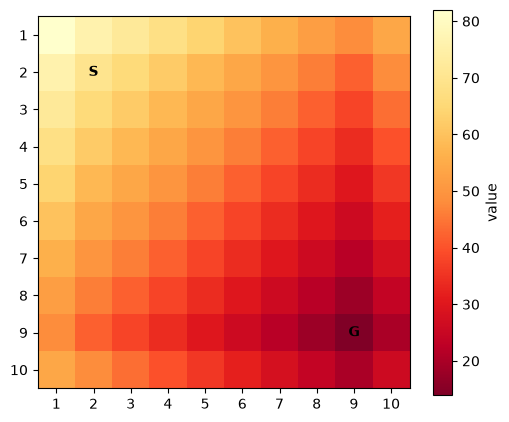

In [7]:
f = g + 5 * h_manhattan
print(f)
show_values(f)

Using $W<1$ makes the search behave more like uniform-cost search (BFS when every step has the same cost), exploring the area around $S$ first. A fraction of an admissible heuristic remains admissible, so optimality is guaranteed.

[[10.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  13.5]
 [ 8.5  7.   7.5  8.   8.5  9.   9.5 10.  10.5 12. ]
 [ 9.   7.5  8.   8.5  9.   9.5 10.  10.5 11.  12.5]
 [ 9.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 13. ]
 [10.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  13.5]
 [10.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 14. ]
 [11.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  14.5]
 [11.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5 15. ]
 [12.  10.5 11.  11.5 12.  12.5 13.  13.5 14.  15.5]
 [13.5 12.  12.5 13.  13.5 14.  14.5 15.  15.5 17. ]]


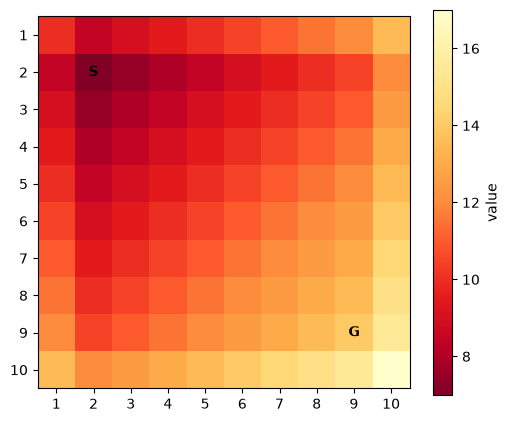

In [8]:
f = g + 0.5 * h_manhattan
print(f)
show_values(f)

## GBFS with Euclidean Distance for $h(n)$

Euclidean distance is the $L_2$ norm: $L_2(a,b) = \sqrt{(a_x-b_x)^2 + (a_y-b_y)^2}$. It is not perfect when the true cost follows Manhattan distance, but it is admissible: $h(n) \leq h^*(n)$.

[[11.3137 10.6301 10.      9.434   8.9443  8.544   8.2462  8.0623  8.
   8.0623]
 [10.6301  9.8995  9.2195  8.6023  8.0623  7.6158  7.2801  7.0711  7.
   7.0711]
 [10.      9.2195  8.4853  7.8102  7.2111  6.7082  6.3246  6.0828  6.
   6.0828]
 [ 9.434   8.6023  7.8102  7.0711  6.4031  5.831   5.3852  5.099   5.
   5.099 ]
 [ 8.9443  8.0623  7.2111  6.4031  5.6569  5.      4.4721  4.1231  4.
   4.1231]
 [ 8.544   7.6158  6.7082  5.831   5.      4.2426  3.6056  3.1623  3.
   3.1623]
 [ 8.2462  7.2801  6.3246  5.3852  4.4721  3.6056  2.8284  2.2361  2.
   2.2361]
 [ 8.0623  7.0711  6.0828  5.099   4.1231  3.1623  2.2361  1.4142  1.
   1.4142]
 [ 8.      7.      6.      5.      4.      3.      2.      1.      0.
   1.    ]
 [ 8.0623  7.0711  6.0828  5.099   4.1231  3.1623  2.2361  1.4142  1.
   1.4142]]


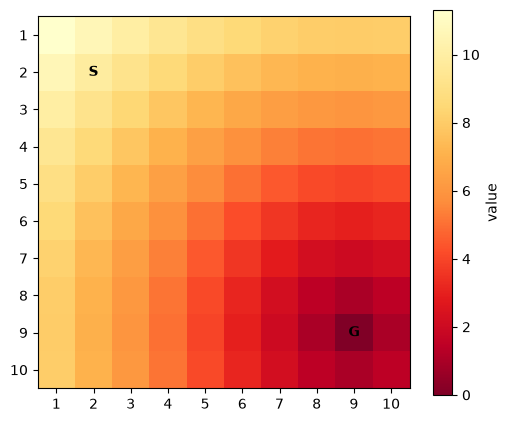

In [9]:
h_euclidean = np.hypot(rows - goal[0], columns - goal[1])
print(h_euclidean)
show_values(h_euclidean)

## A* with Euclidean Distance for $h(n)$

[[13.3137 11.6301 12.     12.434  12.9443 13.544  14.2462 15.0623 16.
  17.0623]
 [11.6301  9.8995 10.2195 10.6023 11.0623 11.6158 12.2801 13.0711 14.
  15.0711]
 [12.     10.2195 10.4853 10.8102 11.2111 11.7082 12.3246 13.0828 14.
  15.0828]
 [12.434  10.6023 10.8102 11.0711 11.4031 11.831  12.3852 13.099  14.
  15.099 ]
 [12.9443 11.0623 11.2111 11.4031 11.6569 12.     12.4721 13.1231 14.
  15.1231]
 [13.544  11.6158 11.7082 11.831  12.     12.2426 12.6056 13.1623 14.
  15.1623]
 [14.2462 12.2801 12.3246 12.3852 12.4721 12.6056 12.8284 13.2361 14.
  15.2361]
 [15.0623 13.0711 13.0828 13.099  13.1231 13.1623 13.2361 13.4142 14.
  15.4142]
 [16.     14.     14.     14.     14.     14.     14.     14.     14.
  16.    ]
 [17.0623 15.0711 15.0828 15.099  15.1231 15.1623 15.2361 15.4142 16.
  17.4142]]


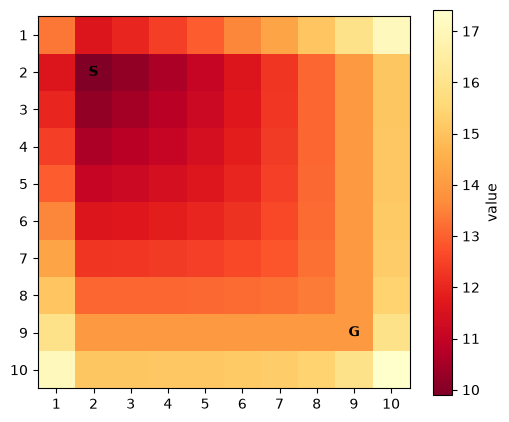

In [10]:
f = g + h_euclidean
print(f)
show_values(f)

**Note:** Euclidean and Manhattan geometry do not mix well here; the gradient is actually from the goal toward the start.

A* expands every node with $f(n)<C^*$ and some nodes with $f(n)=C^*$. These nodes are shown below.

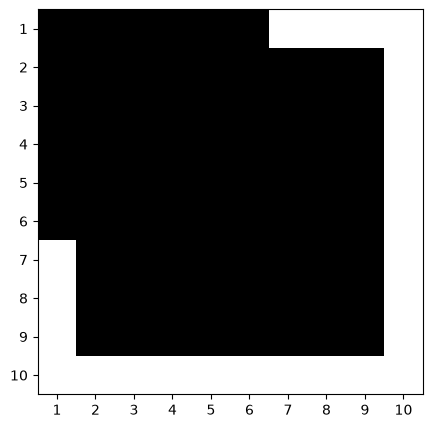

In [11]:
optimal_cost = f[tuple(goal)]
show_values(f <= optimal_cost, cmap="Greys", colorbar=False)

## What if we can also move diagonally at a cost of 1?

Distances are now measured by the $L_\infty$ (maximum) norm: $L_\infty(a,b) = \max(|a_x-b_x|, |a_y-b_y|)$.

[[ 9  9  9 10 11 12 13 14 15 16]
 [ 9  7  8  9 10 11 12 13 14 15]
 [ 9  8  7  8  9 10 11 12 13 14]
 [10  9  8  7  8  9 10 11 12 13]
 [11 10  9  8  7  8  9 10 11 12]
 [12 11 10  9  8  7  8  9 10 11]
 [13 12 11 10  9  8  7  8  9 10]
 [14 13 12 11 10  9  8  7  8  9]
 [15 14 13 12 11 10  9  8  7  9]
 [16 15 14 13 12 11 10  9  9  9]]


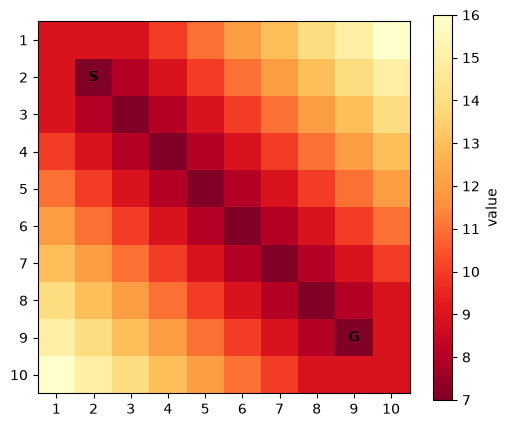

In [12]:
g_maximum = np.maximum(np.abs(rows - start[0]), np.abs(columns - start[1]))
h_maximum = np.maximum(np.abs(rows - goal[0]), np.abs(columns - goal[1]))
f = g_maximum + h_maximum
print(f)
show_values(f)

## What if we could move any distance in any direction at any angle?

Distances and costs are now Euclidean. The squares form only a search grid of sample locations; every location between them is also possible. A larger grid would provide a more detailed visualization. The Euclidean heuristic works perfectly in this setting.

[[12.7279 11.6301 11.4142 11.67   12.1065 12.6671 13.3452 14.145  15.0711
  16.1245]
 [11.6301  9.8995 10.2195 10.6023 11.0623 11.6158 12.2801 13.0711 14.
  15.0711]
 [11.4142 10.2195  9.8995 10.0463 10.3734 10.8313 11.4236 12.1655 13.0711
  14.145 ]
 [11.67   10.6023 10.0463  9.8995 10.0087 10.3031 10.7703 11.4236 12.2801
  13.3452]
 [12.1065 11.0623 10.3734 10.0087  9.8995 10.     10.3031 10.8313 11.6158
  12.6671]
 [12.6671 11.6158 10.8313 10.3031 10.      9.8995 10.0087 10.3734 11.0623
  12.1065]
 [13.3452 12.2801 11.4236 10.7703 10.3031 10.0087  9.8995 10.0463 10.6023
  11.67  ]
 [14.145  13.0711 12.1655 11.4236 10.8313 10.3734 10.0463  9.8995 10.2195
  11.4142]
 [15.0711 14.     13.0711 12.2801 11.6158 11.0623 10.6023 10.2195  9.8995
  11.6301]
 [16.1245 15.0711 14.145  13.3452 12.6671 12.1065 11.67   11.4142 11.6301
  12.7279]]


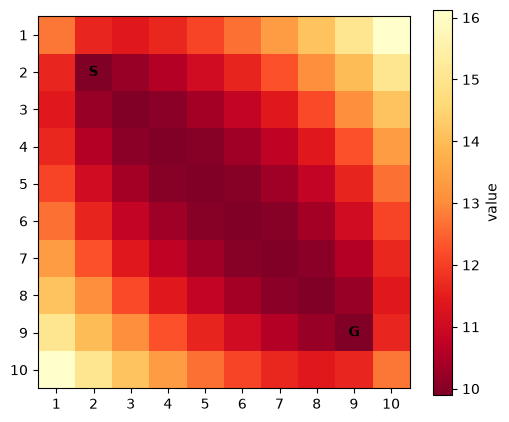

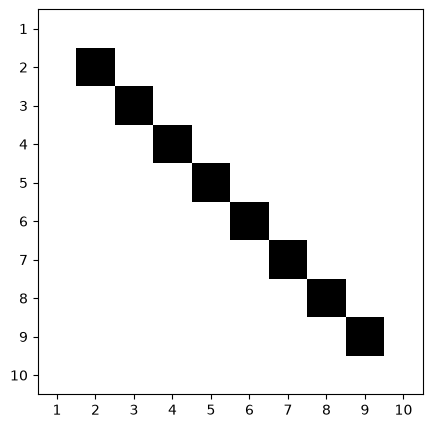

In [13]:
g_euclidean = np.hypot(rows - start[0], columns - start[1])
f = g_euclidean + h_euclidean
print(f)
show_values(f)

# Locations that A* may expand
optimal_cost = f[tuple(goal)]
show_values(f <= optimal_cost, cmap="Greys", colorbar=False)

Using Manhattan distance for the heuristic still points toward the goal, but A* is no longer guaranteed to be optimal. Manhattan distance can overestimate the true Euclidean distance, making it inadmissible.

[[17.4142 16.     15.4142 15.2361 15.1623 15.1231 15.099  15.0828 15.0711
  17.0623]
 [16.     14.     14.     14.     14.     14.     14.     14.     14.
  16.    ]
 [15.4142 14.     13.4142 13.2361 13.1623 13.1231 13.099  13.0828 13.0711
  15.0623]
 [15.2361 14.     13.2361 12.8284 12.6056 12.4721 12.3852 12.3246 12.2801
  14.2462]
 [15.1623 14.     13.1623 12.6056 12.2426 12.     11.831  11.7082 11.6158
  13.544 ]
 [15.1231 14.     13.1231 12.4721 12.     11.6569 11.4031 11.2111 11.0623
  12.9443]
 [15.099  14.     13.099  12.3852 11.831  11.4031 11.0711 10.8102 10.6023
  12.434 ]
 [15.0828 14.     13.0828 12.3246 11.7082 11.2111 10.8102 10.4853 10.2195
  12.    ]
 [15.0711 14.     13.0711 12.2801 11.6158 11.0623 10.6023 10.2195  9.8995
  11.6301]
 [17.0623 16.     15.0623 14.2462 13.544  12.9443 12.434  12.     11.6301
  13.3137]]


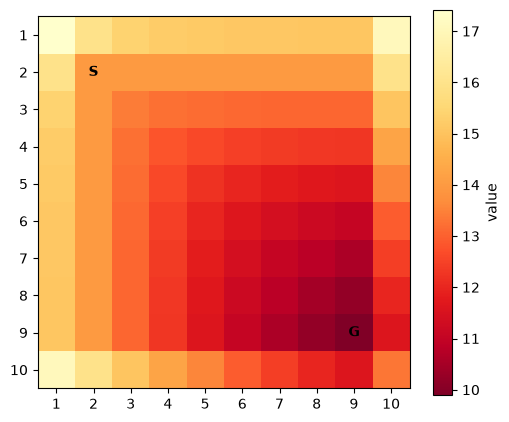

In [14]:
f = g_euclidean + h_manhattan
print(f)
show_values(f)

**Note:** The search still starts at $S$ and follows the gradient directly toward $G$.